# Setup

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

import os

In [3]:
import logging
import sys
sys.path.append("../")

from utils.seed_all import seed_all
from metrics.factory import MetricsFactory

DEFAULT_SEED = 10
seed_all(DEFAULT_SEED)

formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger('sequence_log')
logger.setLevel(logging.INFO)

console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

In [4]:
def plot_img_loss(img_loss, min=None, max=None, targets=[], name='Mean Image Loss Map'):
    plt.figure(figsize=(10, 8))  # Adjust size as needed
    plt.imshow(img_loss, cmap='gray_r', aspect='auto', interpolation='nearest', vmin=min, vmax=max)
    plt.colorbar(label='Normalized Loss')

    # Draw horizontal lines for rows with label == 1
    for i, lbl in enumerate(targets):
        if lbl != 'Normal':
            plt.axhline(i, color='red', linewidth=1.5, alpha=0.2)  # top edge
            # plt.axhline(i + 0.5, color='red', linewidth=1.5, alpha=0.1)  # bottom edge

    plt.xlabel("Byte Index")
    plt.ylabel("Window Index")
    plt.title(name)
    plt.tight_layout()
    plt.show()
    plt.close()

In [5]:
def load_data(base_file):
    with open(f'{base_file}/config.yaml', "r") as f:
        config = yaml.safe_load(f)
    path = f'{base_file}/test_labels_predictions.pt'
    cache = torch.load(path, weights_only=False)
    y_true, y_out = cache['y_true'], cache['y_scores']
    y_pred, y_scores = y_out
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)
    y_true['scores'] = y_scores.mean(axis=(1, 2))

    return y_true, y_pred, y_scores, config

In [6]:
def get_window_metrics(base_path):
    windows = {}

    runs = [f for f in os.listdir(base_path)]
    for run in runs:
        run_path = f'{base_path}/{run}'
        print(run_path)

        if not os.path.exists(f'{run_path}/train_labels_predictions.pt'):
            continue

        try:
            with open(f'{run_path}/config.yaml', "r") as f:
                config = yaml.safe_load(f)
            path = f'{run_path}/train_labels_predictions.pt'
            cache = torch.load(path, weights_only=False)
            y_true, y_out = cache['y_true'], cache['y_scores']
            y_pred, y_scores = y_out
            y_pred = np.array(y_pred)
            y_scores = np.array(y_scores)
            y_true['scores'] = y_scores.mean(axis=(1, 2))

            y_true_benign = y_true[y_true["label"] == 'Normal']
            mean = y_true_benign["scores"].mean()
            std = y_true_benign["scores"].std()
            windows[config['pre_processing']['window_size']] = {'mean': mean, 'std': std}
        except:
            continue

    return windows

In [7]:
def density_function(y_true_benign, quantile=0.9999):
    threshold = y_true_benign["scores"].quantile(quantile)

    # Calculate mean and std
    mean = y_true_benign["scores"].mean()
    std = y_true_benign["scores"].std()

    # Plot histogram + KDE
    # y_true_benign["scores"].plot(kind="hist", bins=20, density=True, alpha=0.6, edgecolor="black")
    y_true_benign["scores"].plot(kind="kde")

    # Add mean line
    plt.axvline(mean, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean:.2f}")

    # Add ±1 std lines
    plt.axvline(mean - std, color="blue", linestyle=":", linewidth=2, label=f"-1 Std = {mean-std:.2f}")
    plt.axvline(mean + std, color="blue", linestyle=":", linewidth=2, label=f"+1 Std = {mean+std:.2f}")
    plt.axvline(threshold, color="yellow", linestyle=":", linewidth=2, label=f"Quantile={quantile}")

    plt.xlabel("Scores")
    plt.title("Scores Distribution with Mean & Std")
    plt.legend()
    plt.show()

In [8]:
def plot_multi_channel(y_preds, y_trues=None, n_channels=10):
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 3*n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]  # handle single channel case

    for i in range(n_channels):
        ax = axes[i]
        y_pred = y_preds[i]
        y_true = None if y_trues is None else y_trues[i]

        if y_true is not None:
            x_true = np.arange(len(y_true))
            ax.plot(x_true, y_true, marker='x', label="True", color="red")
            start_idx = len(y_true) - len(y_pred)
            x_pred = np.arange(start_idx, start_idx + len(y_pred))
        else:
            x_pred = np.arange(len(y_pred))

        ax.plot(x_pred, y_pred, marker='o', label="Pred", color="blue")
        ax.set_title(f"Channel {i+1}")
        ax.grid(True)
        ax.legend()

        ax.set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

In [9]:
def load_x(path: str, load_subset = None) -> tuple[np.ndarray, pd.DataFrame]:
        
        files = [f for f in os.listdir(path)]
        files.sort()
        all_X, all_y = [], []

        for file in files:
            cache = torch.load(f"{path}/{file}", weights_only=False)
            all_X.append(cache['X'])
            all_y.append(cache['y'])

        X = np.concatenate(all_X, axis=0)
        y = pd.concat(all_y, axis=0).reset_index(drop=True)

        if load_subset is not None:

            indices = np.random.choice(len(X), size=int(load_subset*len(X)), replace=False)
            X = X[indices]
            y = y.iloc[indices].reset_index(drop=True)

        return X, y

# Base config

In [21]:
y_true, y_pred, y_scores, config = load_data('../runs/tcn_pred_TOWIDS_20251215_102028')
y_true_benign = y_true[y_true["label"] == 'Normal']

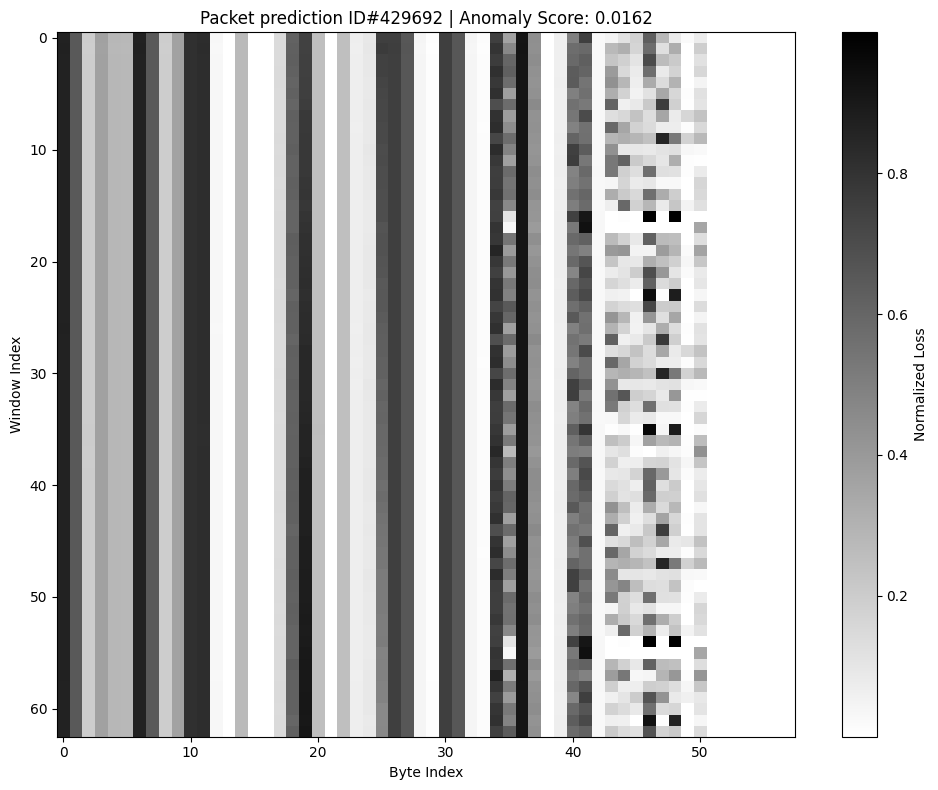

In [12]:
idx = y_true_benign.index[0]
plot_img_loss(y_pred[idx], name=f'Packet prediction ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

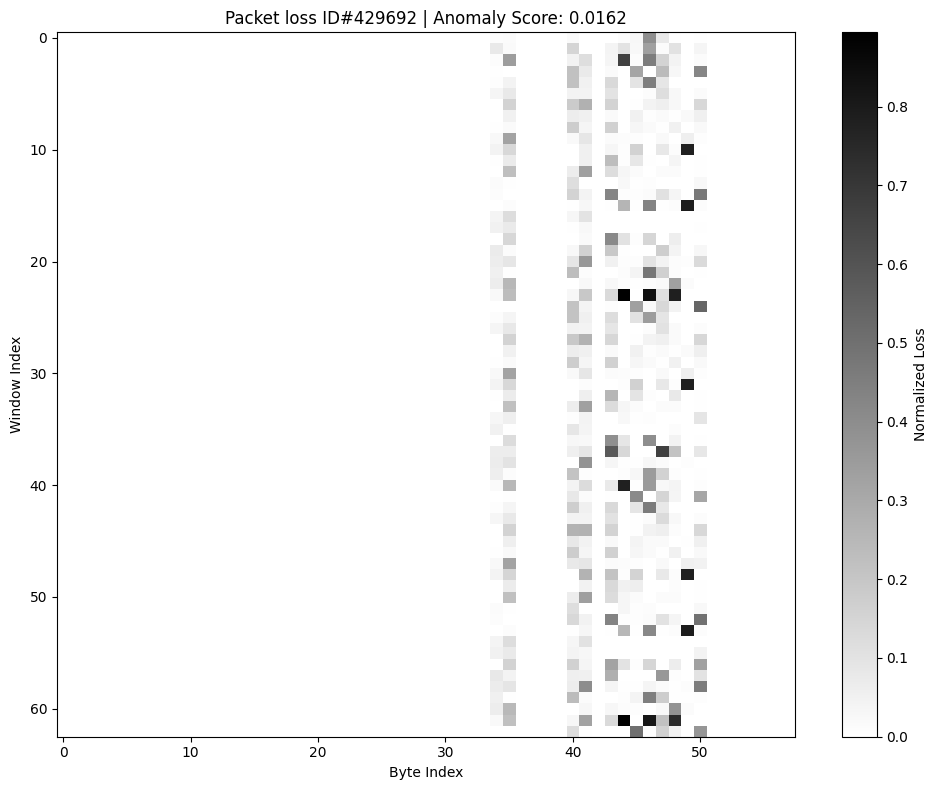

In [13]:
idx = y_true_benign.index[0]
plot_img_loss(y_scores[idx], name=f'Packet loss ID#{y_true['start_idx'].iloc[idx]} | Anomaly Score: {y_true['scores'].iloc[idx]:.4f}')

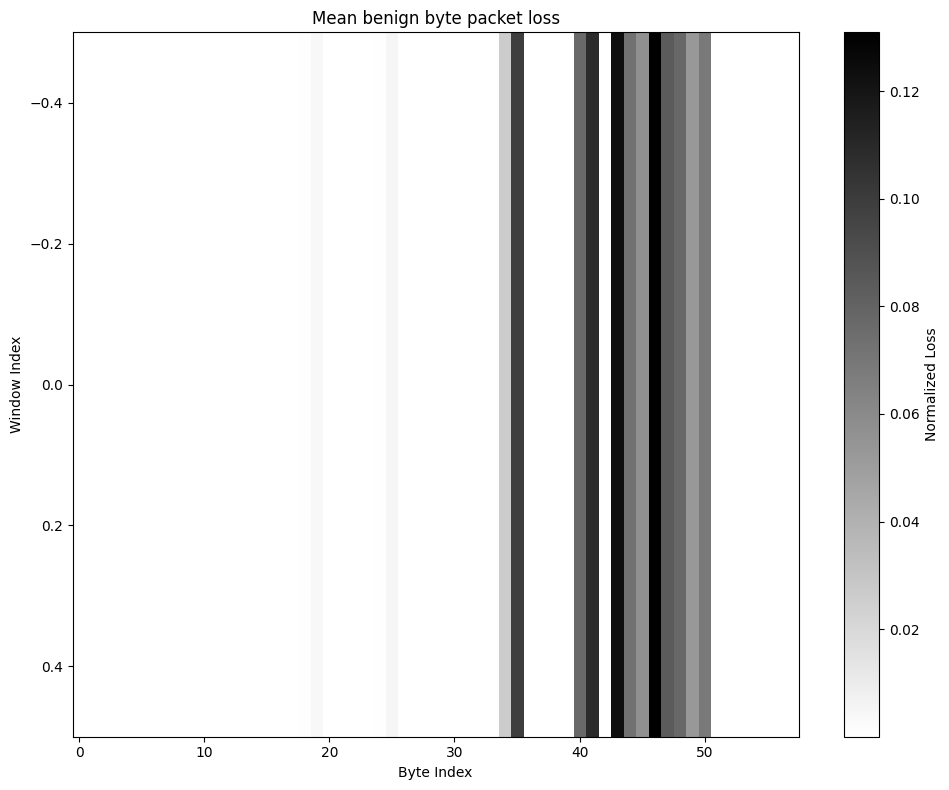

In [14]:
plot_img_loss(np.expand_dims(y_scores[y_true['label'] == 'Normal'].mean(1).mean(0), axis=0), name=f'Mean benign byte packet loss')

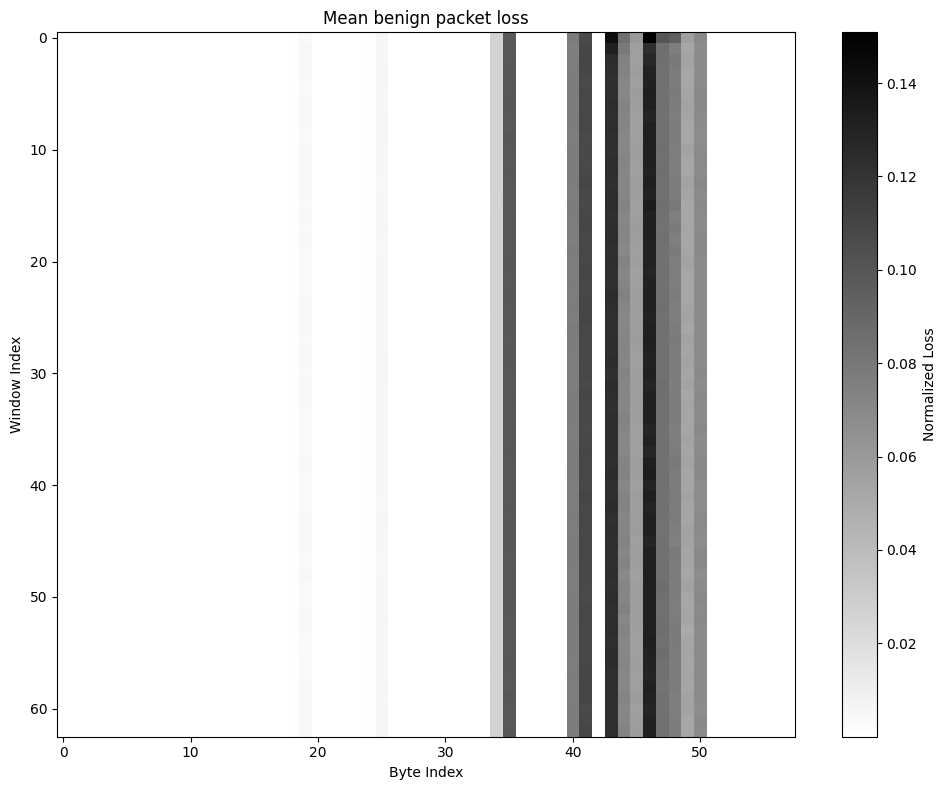

In [15]:
plot_img_loss(y_scores[y_true['label'] == 'Normal'].mean(0), name=f'Mean benign packet loss')

In [16]:
def get_threshold_table(y_true_benign):
    ts = [0.95, 0.98, 0.99, 0.999, 0.9999]
    r = {}
    for t in ts:
        threshold = y_true_benign["scores"].quantile(t)
        fp = y_true_benign[y_true_benign["scores"] > threshold]
        r[t] = {
            'count': len(fp),
            'mean': fp['scores'].mean(),
            'std': fp['scores'].std(),
            # 'fp': fp
        }
    return r

In [17]:
t_results = get_threshold_table(y_true_benign)

In [18]:
pd.DataFrame(t_results)

,0.9500,0.9800,0.9900,0.9990,0.9999
count,1823.000000,729.000000,365.000000,37.000000,4.00000
mean,0.019891,0.020565,0.021147,0.023810,0.02475
std,0.000833,0.000967,0.001085,0.000576,0.00029


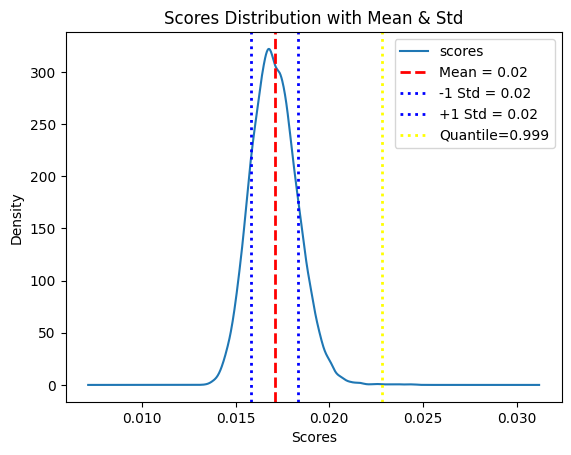

In [19]:
q = 0.999
density_function(y_true_benign, quantile=q)

In [66]:
y_true.sort_values('start_idx').shape

(55837, 5)

In [22]:
fp = y_true[(y_true["scores"] < 66.14112854003906) & (y_true['label'] == 'CAN DoS')]

In [74]:
y_true.head()

,index,label,start_idx,desc_windows,scores
0,59454,Normal,429692,"[Normal, Normal, Normal, Normal, Normal, Norma...",59.269855
1,26351,Normal,69082,"[Normal, Normal, Normal, Normal, Normal, Norma...",63.005997
2,462916,Normal,648869,"[Normal, Normal, Normal, Normal, Normal, Norma...",57.655800
3,556393,Normal,50887,"[Normal, Normal, Normal, Normal, Normal, Norma...",64.152191
4,466524,Normal,539150,"[Normal, Normal, Normal, Normal, Normal, Norma...",61.500488


In [70]:
idx = fp.index
y_scores[idx].shape

(5410, 63, 58)

In [80]:
y_true['desc_windows'].iloc[idx].iloc[2]

array(['Normal', 'Normal', 'CAN DoS', 'Normal', 'Normal', 'CAN DoS',
       'Normal', 'CAN DoS', 'Normal', 'CAN DoS', 'Normal', 'CAN DoS',
       'Normal', 'CAN DoS', 'Normal', 'Normal', 'CAN DoS', 'Normal',
       'CAN DoS', 'CAN DoS', 'Normal', 'CAN DoS', 'CAN DoS', 'CAN DoS',
       'CAN DoS', 'CAN DoS', 'Normal', 'CAN DoS', 'Normal', 'CAN DoS',
       'CAN DoS', 'Normal', 'CAN DoS', 'CAN DoS', 'CAN DoS', 'Normal',
       'CAN DoS', 'Normal', 'CAN DoS', 'Normal', 'CAN DoS', 'Normal',
       'CAN DoS', 'Normal', 'Normal', 'CAN DoS', 'CAN DoS', 'Normal',
       'Normal', 'CAN DoS', 'Normal', 'CAN DoS', 'Normal', 'Normal',
       'CAN DoS', 'Normal', 'CAN DoS', 'Normal', 'CAN DoS', 'Normal',
       'CAN DoS', 'Normal', 'CAN DoS', 'Normal'], dtype=object)

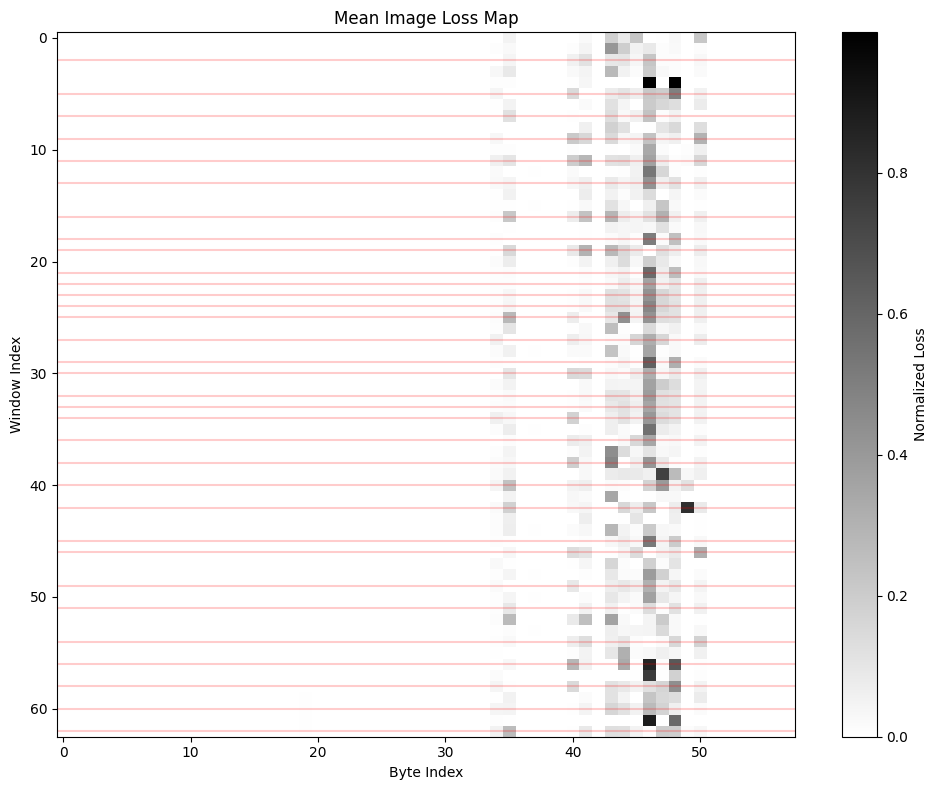

In [81]:
idx = fp.index
plot_img_loss(y_scores[idx][2], targets=y_true['desc_windows'].iloc[idx].iloc[2]) # , name=f'False positive mean packet loss ID#{y_true['start_idx'].iloc[idx]} | Quantile={q}')

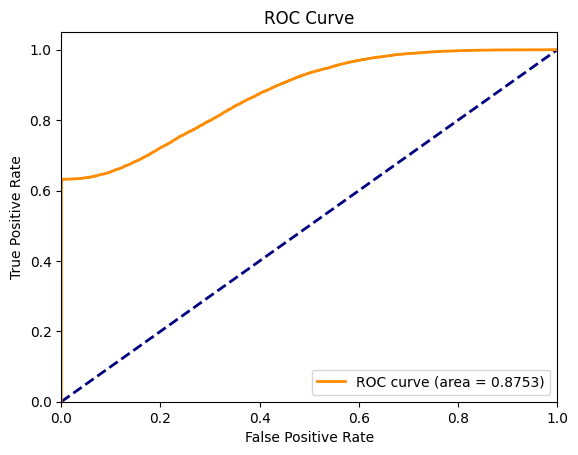

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve

fpr, tpr, thresholds = roc_curve([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
aucroc = roc_auc_score([i != 'Normal' for i in y_true['label'].values], y_true['scores'])
plt.figure()
plt.plot([0, 2], [0, 2], color="navy", lw=2, linestyle="--")
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (area = {aucroc:.4f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
plt.close()

In [36]:
metrics_handler = MetricsFactory().get({'metrics': {'name': 'ae' }}, logger)
metrics = metrics_handler.get_overall_metrics(y_true, (y_pred, y_scores), threshold=66.14112854003906)

2025-12-16 10:22:26,108 | INFO | Metrics 
{
    "AUCROC": 0.8753406333319302,
    "Accuracy": 0.7730537099056182,
    "TPR": 0.7209302325581395,
    "FPR": 0.1992097464603227,
    "Precision": 0.6582081822889695,
    "F1-score": 0.6881429344883596,
    "optimal_threshold": 66.14112854003906,
    "mean": 62.40867614746094,
    "std": 4.563825607299805,
    "tpr_per_attack": {
        "CAN Replay": 0.9998777804937669,
        "CAN DoS": 0.24388539482879107,
        "Switch MAC Flooding": 0.9997534516765286,
        "Normal": 0.8007902535396774,
        "Attack": 0.7209302325581395
    },
    "aucroc_per_attack": {
        "Switch MAC Flooding": 0.9997311267542519,
        "CAN Replay": 0.9998731793203899,
        "CAN DoS": 0.6624191612706429
    }
}


In [53]:
y_true.head()

,index,label,start_idx,desc_windows,scores
0,59454,Normal,429692,"[Normal, Normal, Normal, Normal, Normal, Norma...",59.269855
1,26351,Normal,69082,"[Normal, Normal, Normal, Normal, Normal, Norma...",63.005997
2,462916,Normal,648869,"[Normal, Normal, Normal, Normal, Normal, Norma...",57.655800
3,556393,Normal,50887,"[Normal, Normal, Normal, Normal, Normal, Norma...",64.152191
4,466524,Normal,539150,"[Normal, Normal, Normal, Normal, Normal, Norma...",61.500488


In [150]:
X, y = load_x('../data/tow-ids-dataset/processed/train_sliding-window_wsize_64_wstride_1_n_58_IP_UDP_subset_0.1')

In [153]:
idx = y_true_benign.index[0]
start_idx = y_true['start_idx'].iloc[idx]
test_idx = y[y['start_idx'] == start_idx].index[0]
(start_idx, test_idx)

(np.int64(982855), np.int64(33819))

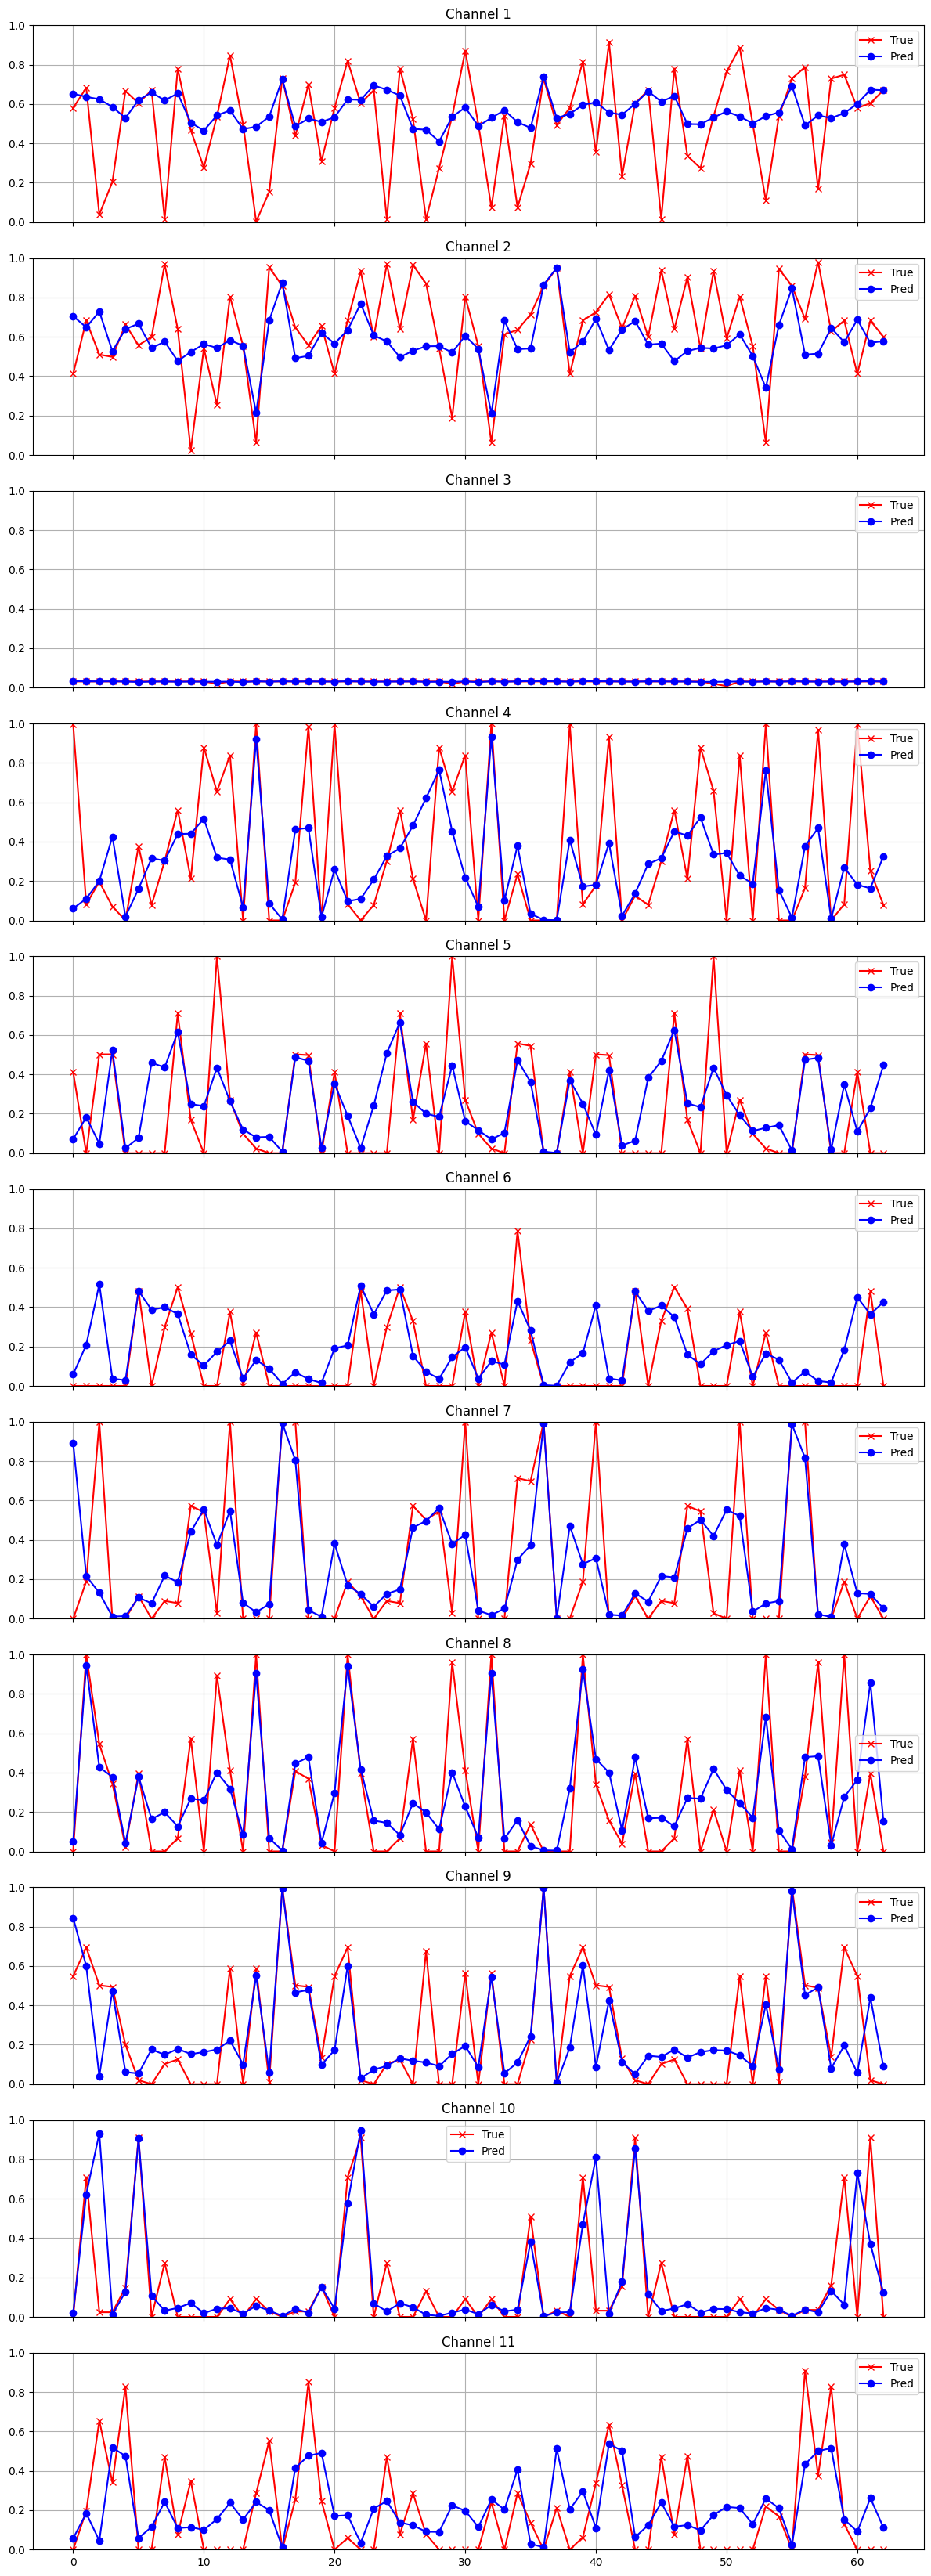

In [187]:
start_channel = 40
end_channel = 51
plot_multi_channel(y_pred[idx].T[start_channel:end_channel], 
                   X[test_idx][1:].T[start_channel:end_channel], 
                   n_channels=end_channel-start_channel)

In [53]:
from sklearn.metrics import roc_curve
def get_threshold_youden_index(y_true, y_scores):
    # Calculate Youden index to determine optimal threshold
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    youden_index = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_index]
    return optimal_threshold

In [55]:
aux = y_true[(y_true['label'] == 'Normal') | (y_true['label'] == 'CAN DoS')].index
dos_t = get_threshold_youden_index(y_true['label'].apply(lambda x: 0 if x == 'Normal' else 1).iloc[aux], y_true['scores'].iloc[aux])
del aux

In [10]:
X, y = load_x('../data/tow-ids-dataset/processed/test_sliding-window_wsize_64_wstride_1_n_58_IP_UDP_subset_1', load_subset=0.1)

In [57]:
y_true[y_true["scores"] > dos_t]['label'].value_counts()

label
Normal                 20400
CAN Replay              8181
CAN DoS                 6334
Switch MAC Flooding     4055
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

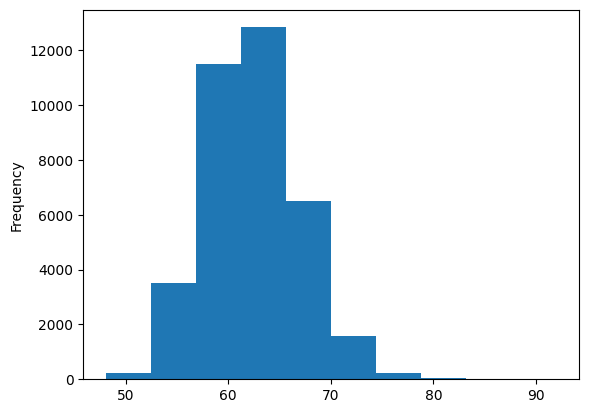

In [64]:
y_true[y_true['label'] == 'Normal']['scores'].plot.hist()

In [58]:
fp = y_true[(y_true["scores"] < dos_t) & (y_true['label'] == 'CAN DoS')]

In [59]:
dos_idx = fp.index

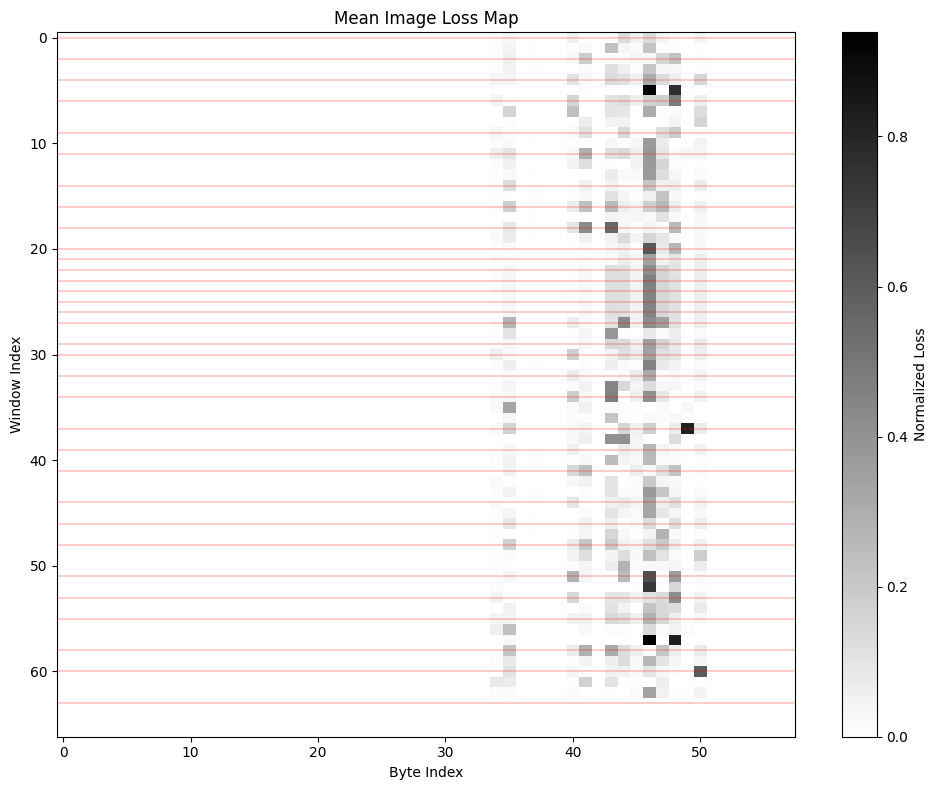

In [60]:
idx = 0
plot_img_loss(y_scores[dos_idx][idx], targets=y['desc_windows'].iloc[dos_idx].iloc[idx])

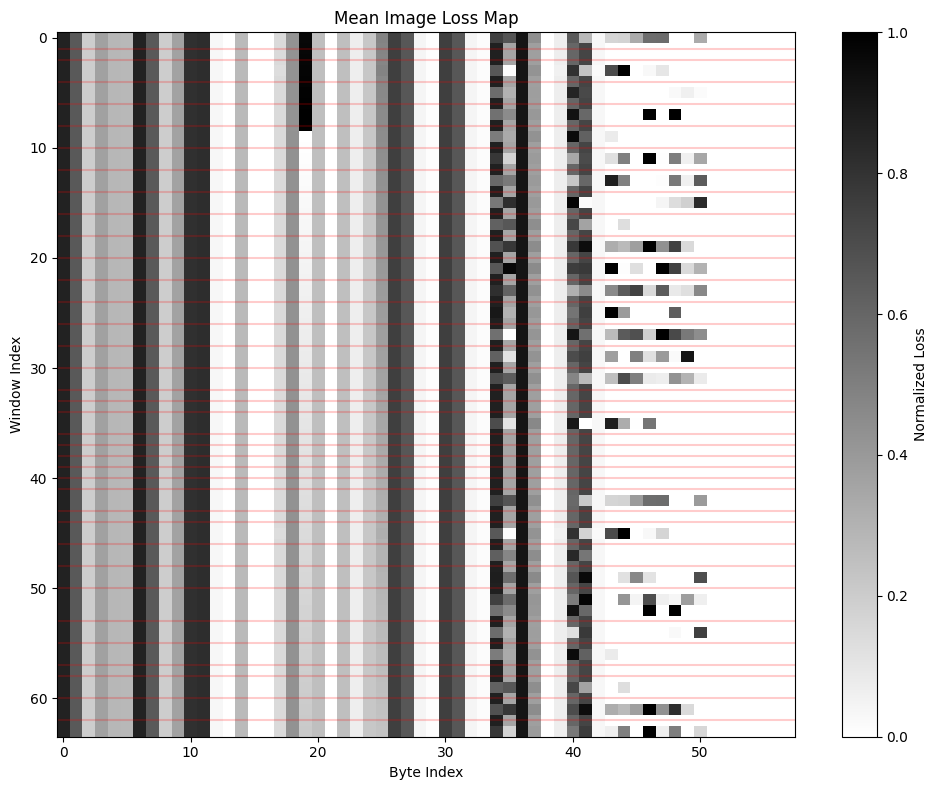

In [48]:
idx = 0
plot_img_loss(X[dos_idx][idx], targets=y['desc_windows'].iloc[dos_idx].iloc[idx])